In [1]:
import seaborn as sns
import math
import json
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from BorutaShap import BorutaShap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

if not hasattr(scipy.stats, 'binom_test'):
    def binom_test_wrapper(x, n=None, p=0.5, alternative='two-sided'):
        k_clean = int(x)
        n_clean = int(n) if n is not None else None
        return scipy.stats.binomtest(k=k_clean, n=n_clean, p=p, alternative=alternative).pvalue
    scipy.stats.binom_test = binom_test_wrapper

In [2]:
FPSIZE = 4096
BORUTA_TRIALS = 20

In [3]:
df = pd.read_csv('../nr_ic_merged.csv')

In [4]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [5]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f9ed6f5fd80>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f9ed6f5fdf0>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f9ed6f5fe60>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f9ed6f5fed0>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f9ed6f5ff40>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f9ed7a0a650>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f9ed7a0a6c0>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f9ed7a0a730>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f9ed7a0a7a0>


In [6]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [8]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [9]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [11]:
import numpy as np
import scipy.stats

if not hasattr(np, 'NaN'):
    np.NaN = np.nan
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

if not hasattr(scipy.stats, 'binom_test'):
    def binom_test_wrapper(x, n=None, p=0.5, alternative='two-sided'):
        k_clean = int(x)
        n_clean = int(n) if n is not None else None

        return scipy.stats.binomtest(k=k_clean, n=n_clean, p=p, alternative=alternative).pvalue

    scipy.stats.binom_test = binom_test_wrapper

from BorutaShap import BorutaShap
import pandas as pd

feature_names = [f"Bit_{i}" for i in range(x.shape[1])]
X_df = pd.DataFrame(x, columns=feature_names)

target_names = encoder.categories_[0]

print(f"Feature Matrix Shape: {X_df.shape}")
print(f"Targets to analyze: {target_names}")

Feature Matrix Shape: (7207, 4096)
Targets to analyze: ['ar' 'era' 'erb' 'gr' 'mr' 'pr']



--- Processing Target: ar ---


  0%|          | 0/20 [00:00<?, ?it/s]

72 attributes confirmed important: ['bit_39', 'bit_2128', 'bit_2322', 'bit_2467', 'bit_3200', 'bit_4090', 'bit_2536', 'bit_1536', 'bit_3839', 'bit_2049', 'bit_2437', 'bit_1309', 'bit_1162', 'bit_807', 'bit_3986', 'bit_334', 'bit_622', 'bit_1601', 'bit_1980', 'bit_1696', 'bit_915', 'bit_1845', 'bit_1862', 'bit_3989', 'bit_1697', 'bit_3798', 'bit_350', 'bit_1721', 'bit_3900', 'bit_2838', 'bit_1337', 'bit_2572', 'bit_3449', 'bit_3511', 'bit_2929', 'bit_3824', 'bit_1959', 'bit_2793', 'bit_1160', 'bit_5', 'bit_2855', 'bit_846', 'bit_1115', 'bit_3738', 'bit_980', 'bit_2722', 'bit_2817', 'bit_621', 'bit_2067', 'bit_3184', 'bit_1236', 'bit_899', 'bit_2438', 'bit_785', 'bit_3524', 'bit_361', 'bit_1535', 'bit_2988', 'bit_371', 'bit_3797', 'bit_289', 'bit_2857', 'bit_3996', 'bit_2944', 'bit_3814', 'bit_2455', 'bit_3259', 'bit_1686', 'bit_1313', 'bit_262', 'bit_194', 'bit_960']
3976 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472

<Figure size 1200x600 with 0 Axes>

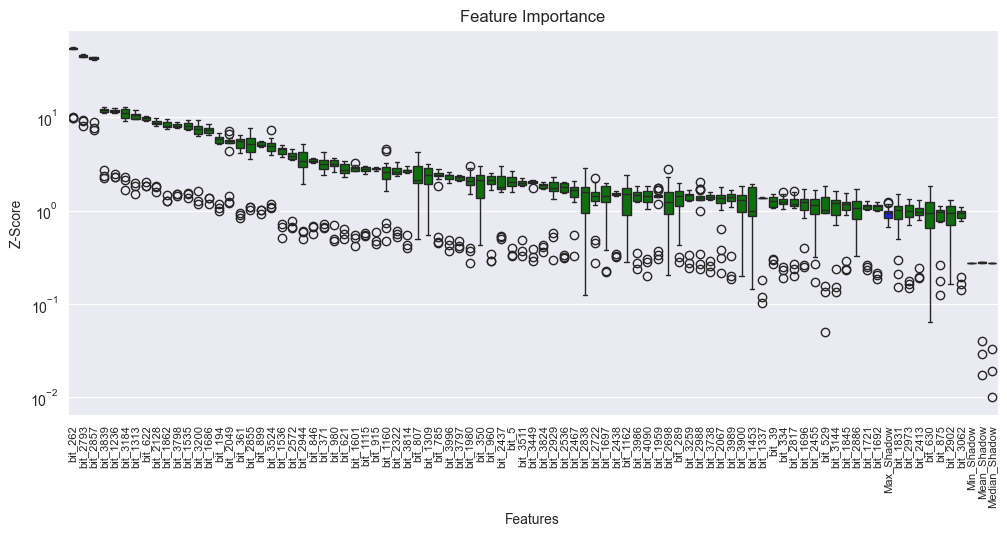

    -> Saved 'boruta_plot_ar.png'
    -> 85 features selected.

--- Processing Target: era ---


  0%|          | 0/20 [00:00<?, ?it/s]

76 attributes confirmed important: ['bit_322', 'bit_2128', 'bit_2467', 'bit_2799', 'bit_3200', 'bit_3580', 'bit_102', 'bit_3839', 'bit_2698', 'bit_3650', 'bit_1233', 'bit_1582', 'bit_1696', 'bit_41', 'bit_1009', 'bit_1256', 'bit_350', 'bit_1052', 'bit_2033', 'bit_2742', 'bit_1164', 'bit_1453', 'bit_3475', 'bit_841', 'bit_2436', 'bit_162', 'bit_1308', 'bit_1239', 'bit_1670', 'bit_2091', 'bit_4039', 'bit_2793', 'bit_1160', 'bit_2983', 'bit_2727', 'bit_2429', 'bit_1855', 'bit_4036', 'bit_1847', 'bit_2787', 'bit_2766', 'bit_1088', 'bit_105', 'bit_2722', 'bit_1274', 'bit_3629', 'bit_3108', 'bit_1145', 'bit_2362', 'bit_4030', 'bit_2974', 'bit_1941', 'bit_3184', 'bit_1270', 'bit_3959', 'bit_2004', 'bit_1928', 'bit_3744', 'bit_3781', 'bit_3578', 'bit_361', 'bit_1951', 'bit_3554', 'bit_13', 'bit_3655', 'bit_119', 'bit_2132', 'bit_1357', 'bit_1939', 'bit_3956', 'bit_1686', 'bit_1313', 'bit_1475', 'bit_262', 'bit_194', 'bit_3361']
3944 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'b

<Figure size 1200x600 with 0 Axes>

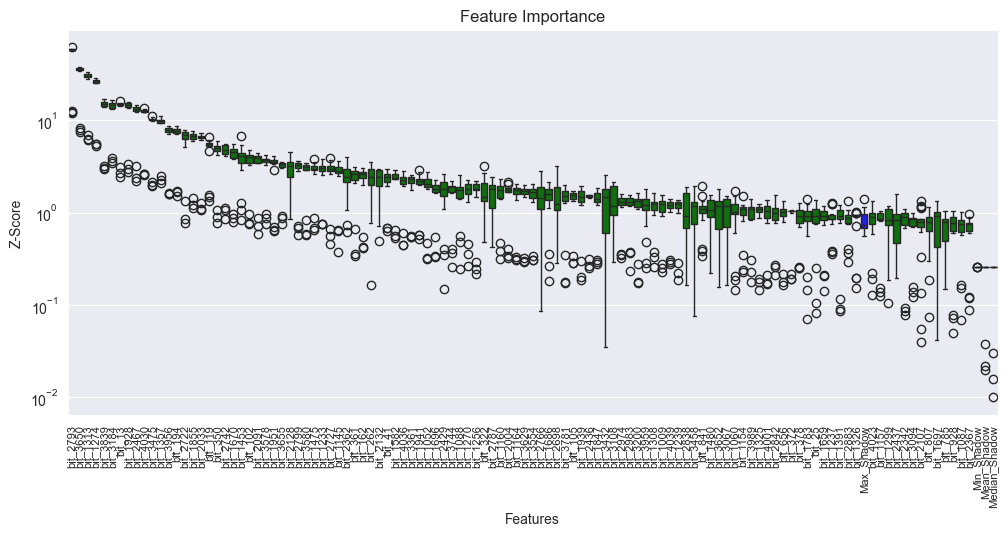

    -> Saved 'boruta_plot_era.png'
    -> 111 features selected.

--- Processing Target: erb ---


  0%|          | 0/20 [00:00<?, ?it/s]

42 attributes confirmed important: ['bit_2467', 'bit_2698', 'bit_3650', 'bit_1233', 'bit_875', 'bit_3802', 'bit_54', 'bit_350', 'bit_3067', 'bit_3087', 'bit_3864', 'bit_162', 'bit_2007', 'bit_2852', 'bit_1670', 'bit_2929', 'bit_3665', 'bit_4057', 'bit_2793', 'bit_2983', 'bit_1855', 'bit_675', 'bit_45', 'bit_4036', 'bit_1088', 'bit_1274', 'bit_3083', 'bit_3556', 'bit_3184', 'bit_2162', 'bit_1692', 'bit_2331', 'bit_1928', 'bit_133', 'bit_3162', 'bit_3105', 'bit_1926', 'bit_4001', 'bit_194', 'bit_1475', 'bit_262', 'bit_2727']
3963 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', 'bit_959', 'bit_3850', 'bit_1285', 'bit_1065', 'bit_3282', 'bit_59', 'bit_245', 'bit_2109', 'bit_2317', 'bit_1922', 'bit_2957', 'bit_3297', 'bit_738', 'bit_2710', 'bit_1112', 'bit_582', 'bit_3140', 'bit_3424', 'bit_3663', 'bit_3857', 'bit_422', 'bit_1223', 'bit_1506', 'bit_688', 'bit_464', 'bit_2222', 'bit_312

<Figure size 1200x600 with 0 Axes>

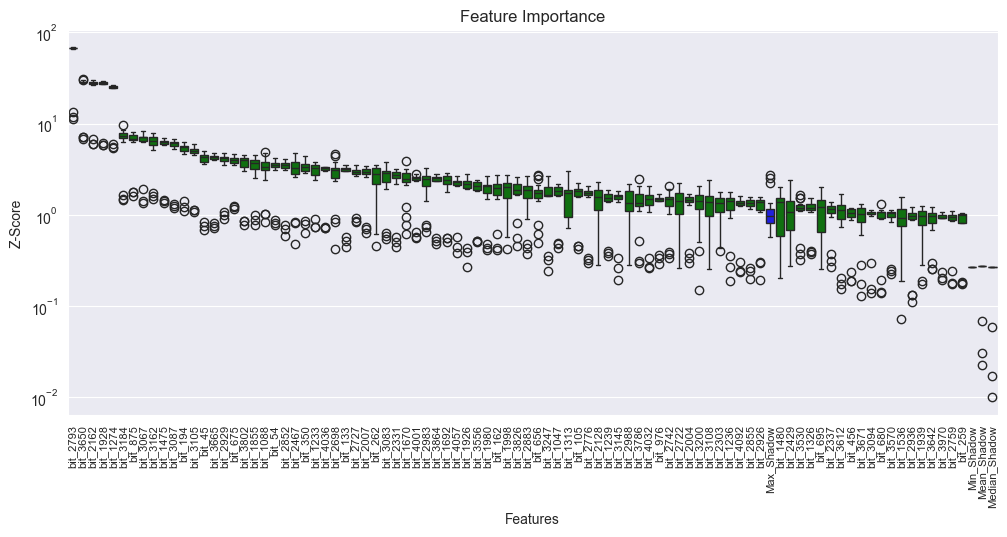

    -> Saved 'boruta_plot_erb.png'
    -> 88 features selected.

--- Processing Target: gr ---


  0%|          | 0/20 [00:00<?, ?it/s]

68 attributes confirmed important: ['bit_1747', 'bit_1154', 'bit_2457', 'bit_3200', 'bit_1536', 'bit_3839', 'bit_1257', 'bit_3650', 'bit_807', 'bit_1279', 'bit_2932', 'bit_2400', 'bit_630', 'bit_350', 'bit_3067', 'bit_2742', 'bit_841', 'bit_3087', 'bit_3612', 'bit_3786', 'bit_2854', 'bit_1436', 'bit_2107', 'bit_3349', 'bit_1670', 'bit_1237', 'bit_2091', 'bit_2793', 'bit_1160', 'bit_2983', 'bit_1147', 'bit_262', 'bit_3458', 'bit_3108', 'bit_1274', 'bit_2604', 'bit_1215', 'bit_1145', 'bit_1553', 'bit_3652', 'bit_2362', 'bit_3770', 'bit_3959', 'bit_1941', 'bit_695', 'bit_1928', 'bit_389', 'bit_361', 'bit_1535', 'bit_333', 'bit_371', 'bit_3082', 'bit_1687', 'bit_3105', 'bit_3211', 'bit_13', 'bit_1421', 'bit_2132', 'bit_2857', 'bit_280', 'bit_2230', 'bit_1970', 'bit_3956', 'bit_2944', 'bit_1313', 'bit_4006', 'bit_1344', 'bit_2727']
3965 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', '

<Figure size 1200x600 with 0 Axes>

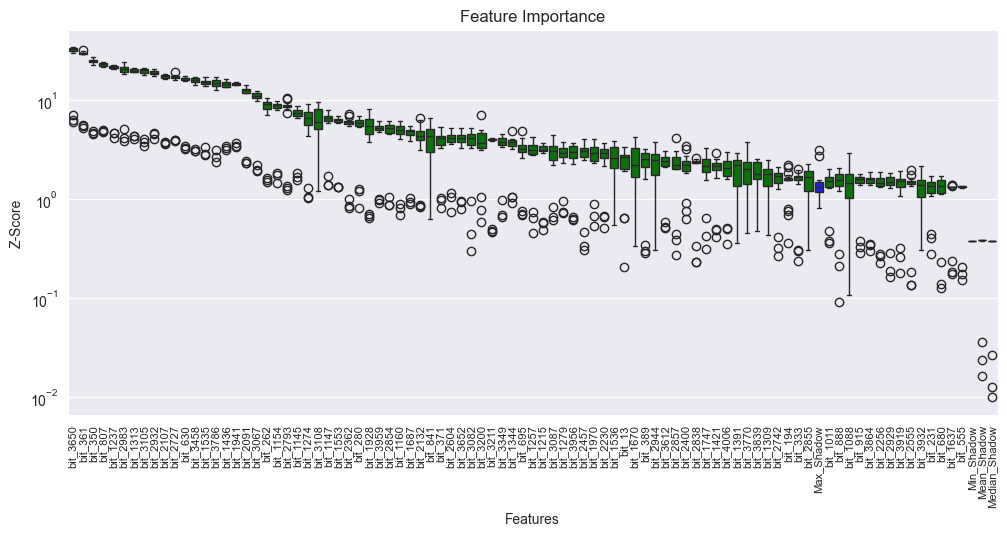

    -> Saved 'boruta_plot_gr.png'
    -> 87 features selected.

--- Processing Target: mr ---


  0%|          | 0/20 [00:00<?, ?it/s]

29 attributes confirmed important: ['bit_1594', 'bit_2049', 'bit_3650', 'bit_630', 'bit_350', 'bit_971', 'bit_1101', 'bit_841', 'bit_1060', 'bit_2303', 'bit_3219', 'bit_2107', 'bit_1670', 'bit_692', 'bit_2929', 'bit_2793', 'bit_1905', 'bit_2766', 'bit_1145', 'bit_2974', 'bit_132', 'bit_441', 'bit_361', 'bit_3782', 'bit_1338', 'bit_4006', 'bit_2518', 'bit_1021', 'bit_262']
4025 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', 'bit_959', 'bit_3850', 'bit_1285', 'bit_1065', 'bit_3282', 'bit_59', 'bit_245', 'bit_2109', 'bit_2317', 'bit_1922', 'bit_2957', 'bit_3297', 'bit_738', 'bit_2710', 'bit_1112', 'bit_582', 'bit_3140', 'bit_3424', 'bit_3663', 'bit_3857', 'bit_422', 'bit_1223', 'bit_1506', 'bit_688', 'bit_464', 'bit_2222', 'bit_3125', 'bit_1281', 'bit_855', 'bit_2643', 'bit_2668', 'bit_1389', 'bit_3320', 'bit_1542', 'bit_2297', 'bit_1626', 'bit_2270', 'bit_22', 'bit_194', 'bit_1784', 'bit_677',

<Figure size 1200x600 with 0 Axes>

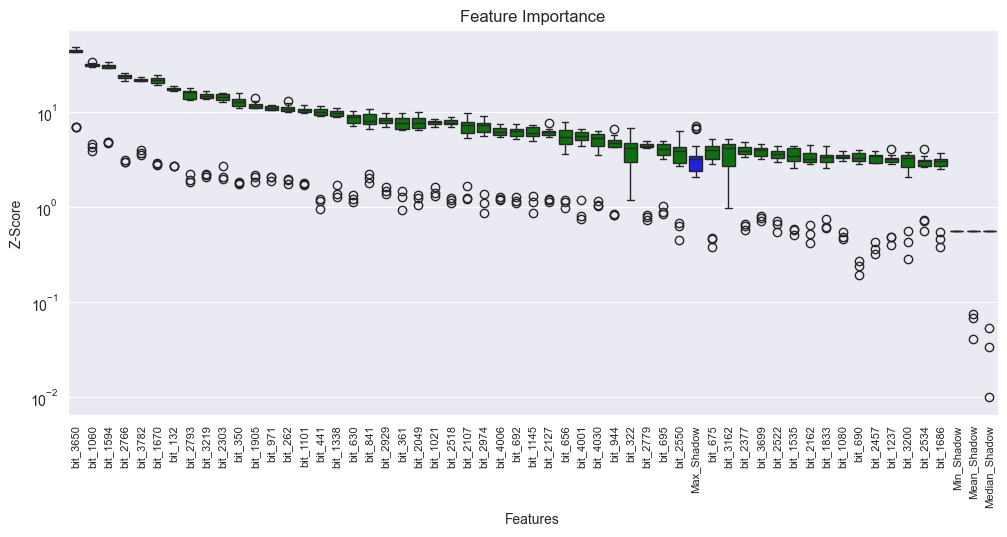

    -> Saved 'boruta_plot_mr.png'
    -> 53 features selected.

--- Processing Target: pr ---


  0%|          | 0/20 [00:00<?, ?it/s]

59 attributes confirmed important: ['bit_1594', 'bit_2290', 'bit_3839', 'bit_2698', 'bit_1257', 'bit_3650', 'bit_2682', 'bit_807', 'bit_372', 'bit_1980', 'bit_3802', 'bit_3500', 'bit_630', 'bit_127', 'bit_3330', 'bit_191', 'bit_253', 'bit_2730', 'bit_2522', 'bit_439', 'bit_2413', 'bit_378', 'bit_2793', 'bit_1160', 'bit_2855', 'bit_3028', 'bit_4041', 'bit_45', 'bit_3733', 'bit_2722', 'bit_1274', 'bit_1638', 'bit_3108', 'bit_1145', 'bit_3873', 'bit_4030', 'bit_35', 'bit_1917', 'bit_1957', 'bit_3184', 'bit_695', 'bit_3875', 'bit_216', 'bit_785', 'bit_361', 'bit_991', 'bit_13', 'bit_3105', 'bit_3655', 'bit_119', 'bit_746', 'bit_2857', 'bit_2944', 'bit_2281', 'bit_34', 'bit_1313', 'bit_1475', 'bit_262', 'bit_960']
3979 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', 'bit_959', 'bit_3850', 'bit_1285', 'bit_1065', 'bit_3282', 'bit_59', 'bit_245', 'bit_2109', 'bit_2317', 'bit_1922', 'bit_

<Figure size 1200x600 with 0 Axes>

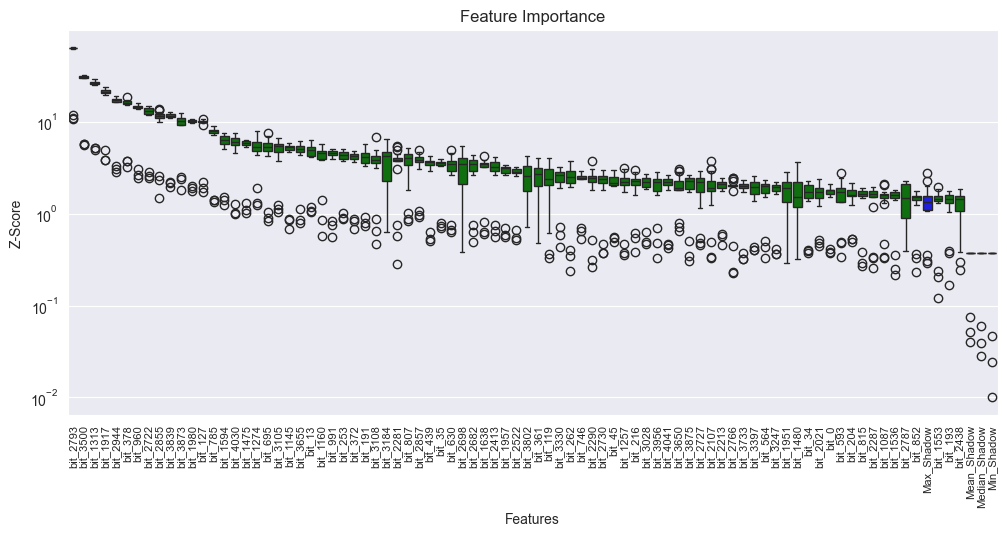

    -> Saved 'boruta_plot_pr.png'
    -> 82 features selected.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BorutaShap import BorutaShap
from xgboost import XGBClassifier

# --- 1. SETUP ---
# Assumptions: 'x', 'y', 'target_names', and 'BORUTA_TRIALS' are already defined
feature_names = [f"bit_{i}" for i in range(x.shape[1])]
X_boruta = pd.DataFrame(x, columns=feature_names)

# Dictionary to store the final list of "kept" features for each target
selected_features_per_target = {}

# XGBoost Configuration
xgb_boruta = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
    eval_metric="logloss"
)

# --- 2. LOOP PER TARGET ---
for i, target_name in enumerate(target_names):
    print(f"\n--- Processing Target: {target_name} ---")

    y_target = pd.Series(y[:, i], name=target_name)

    # Initialize BorutaShap
    selector = BorutaShap(
        model=xgb_boruta,
        importance_measure='shap',
        classification=True
    )

    try:
        # Fit Boruta
        # verbose=True will usually print a text summary automatically
        selector.fit(X=X_boruta, y=y_target, n_trials=BORUTA_TRIALS, sample=False, verbose=True)

        # Cleanup tentative features (optional, but good for finality)
        selector.TentativeRoughFix()

        # --- USE THE BUILT-IN FUNCTION ---
        # This generates the boxplot of Accepted Features vs Shadow Features
        print(f"Generating plot for {target_name}...")

        # We start a new figure to avoid overwriting/stacking
        plt.figure(figsize=(12, 6))

        # 'accepted' shows only the confirmed features.
        # You can use 'all' if you want to see everything (can be messy).
        selector.plot(which_features='accepted', figsize=(12, 5))

        # Save the plot automatically
        safe_name = target_name.replace('/', '_').replace(' ', '_')
        plt.title(f"Boruta Importance: {target_name}")
        plt.tight_layout()
        plt.savefig(f"boruta_plot_{safe_name}.png", dpi=300)
        plt.close() # Close to free memory

        # Store the selected features list for your downstream tasks
        subset = selector.Subset()
        selected_features_per_target[target_name] = subset.columns.tolist()

        print(f"    -> Saved 'boruta_plot_{safe_name}.png'")
        print(f"    -> {len(subset.columns)} features selected.")

    except Exception as e:
        print(f"    -> Failed for {target_name}: {e}")


--- Processing Target: ar ---


  0%|          | 0/20 [00:00<?, ?it/s]

72 attributes confirmed important: ['bit_39', 'bit_2128', 'bit_2322', 'bit_2467', 'bit_3200', 'bit_4090', 'bit_2536', 'bit_1536', 'bit_3839', 'bit_2049', 'bit_2437', 'bit_1309', 'bit_1162', 'bit_807', 'bit_3986', 'bit_334', 'bit_622', 'bit_1601', 'bit_1980', 'bit_1696', 'bit_915', 'bit_1845', 'bit_1862', 'bit_3989', 'bit_1697', 'bit_3798', 'bit_350', 'bit_1721', 'bit_3900', 'bit_2838', 'bit_1337', 'bit_2572', 'bit_3449', 'bit_3511', 'bit_2929', 'bit_3824', 'bit_1959', 'bit_2793', 'bit_1160', 'bit_5', 'bit_2855', 'bit_846', 'bit_1115', 'bit_3738', 'bit_980', 'bit_2722', 'bit_2817', 'bit_621', 'bit_2067', 'bit_3184', 'bit_1236', 'bit_899', 'bit_2438', 'bit_785', 'bit_3524', 'bit_361', 'bit_1535', 'bit_2988', 'bit_371', 'bit_3797', 'bit_289', 'bit_2857', 'bit_3996', 'bit_2944', 'bit_3814', 'bit_2455', 'bit_3259', 'bit_1686', 'bit_1313', 'bit_262', 'bit_194', 'bit_960']
3976 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472

<Figure size 1200x600 with 0 Axes>

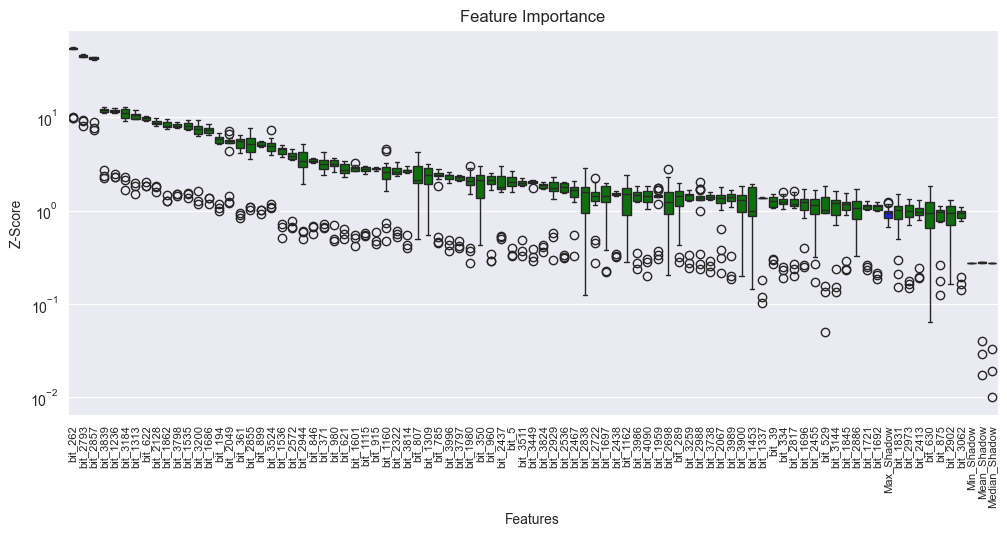

    -> Saved plot and 85 features selected.

--- Processing Target: era ---


  0%|          | 0/20 [00:00<?, ?it/s]

76 attributes confirmed important: ['bit_322', 'bit_2128', 'bit_2467', 'bit_2799', 'bit_3200', 'bit_3580', 'bit_102', 'bit_3839', 'bit_2698', 'bit_3650', 'bit_1233', 'bit_1582', 'bit_1696', 'bit_41', 'bit_1009', 'bit_1256', 'bit_350', 'bit_1052', 'bit_2033', 'bit_2742', 'bit_1164', 'bit_1453', 'bit_3475', 'bit_841', 'bit_2436', 'bit_162', 'bit_1308', 'bit_1239', 'bit_1670', 'bit_2091', 'bit_4039', 'bit_2793', 'bit_1160', 'bit_2983', 'bit_2727', 'bit_2429', 'bit_1855', 'bit_4036', 'bit_1847', 'bit_2787', 'bit_2766', 'bit_1088', 'bit_105', 'bit_2722', 'bit_1274', 'bit_3629', 'bit_3108', 'bit_1145', 'bit_2362', 'bit_4030', 'bit_2974', 'bit_1941', 'bit_3184', 'bit_1270', 'bit_3959', 'bit_2004', 'bit_1928', 'bit_3744', 'bit_3781', 'bit_3578', 'bit_361', 'bit_1951', 'bit_3554', 'bit_13', 'bit_3655', 'bit_119', 'bit_2132', 'bit_1357', 'bit_1939', 'bit_3956', 'bit_1686', 'bit_1313', 'bit_1475', 'bit_262', 'bit_194', 'bit_3361']
3944 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'b

<Figure size 1200x600 with 0 Axes>

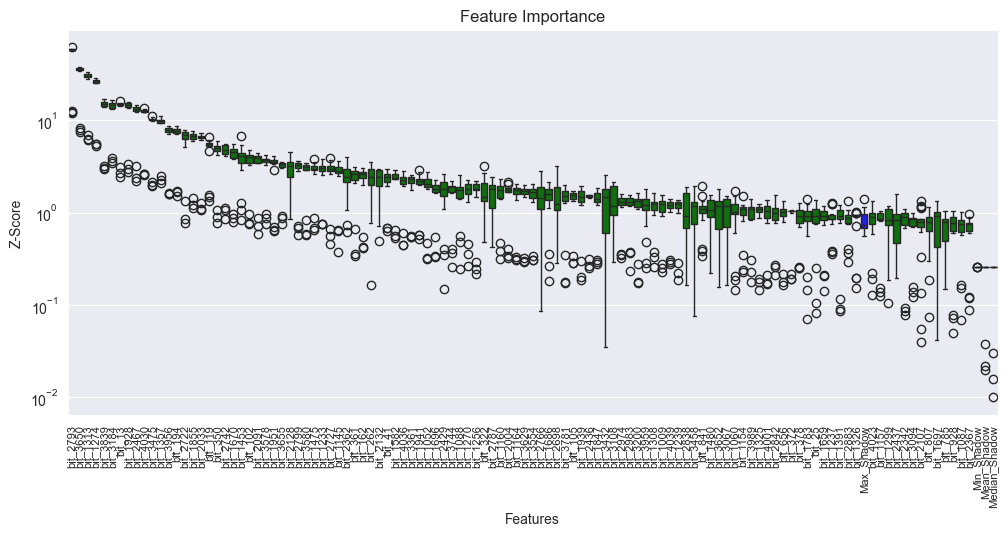

    -> Saved plot and 111 features selected.

--- Processing Target: erb ---


  0%|          | 0/20 [00:00<?, ?it/s]

42 attributes confirmed important: ['bit_2467', 'bit_2698', 'bit_3650', 'bit_1233', 'bit_875', 'bit_3802', 'bit_54', 'bit_350', 'bit_3067', 'bit_3087', 'bit_3864', 'bit_162', 'bit_2007', 'bit_2852', 'bit_1670', 'bit_2929', 'bit_3665', 'bit_4057', 'bit_2793', 'bit_2983', 'bit_1855', 'bit_675', 'bit_45', 'bit_4036', 'bit_1088', 'bit_1274', 'bit_3083', 'bit_3556', 'bit_3184', 'bit_2162', 'bit_1692', 'bit_2331', 'bit_1928', 'bit_133', 'bit_3162', 'bit_3105', 'bit_1926', 'bit_4001', 'bit_194', 'bit_1475', 'bit_262', 'bit_2727']
3963 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', 'bit_959', 'bit_3850', 'bit_1285', 'bit_1065', 'bit_3282', 'bit_59', 'bit_245', 'bit_2109', 'bit_2317', 'bit_1922', 'bit_2957', 'bit_3297', 'bit_738', 'bit_2710', 'bit_1112', 'bit_582', 'bit_3140', 'bit_3424', 'bit_3663', 'bit_3857', 'bit_422', 'bit_1223', 'bit_1506', 'bit_688', 'bit_464', 'bit_2222', 'bit_312

<Figure size 1200x600 with 0 Axes>

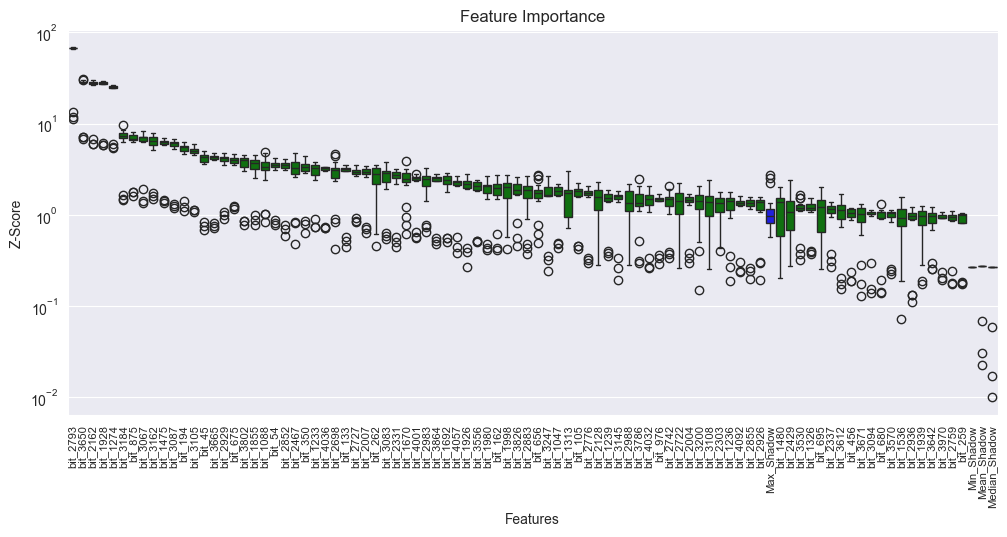

    -> Saved plot and 88 features selected.

--- Processing Target: gr ---


  0%|          | 0/20 [00:00<?, ?it/s]

68 attributes confirmed important: ['bit_1747', 'bit_1154', 'bit_2457', 'bit_3200', 'bit_1536', 'bit_3839', 'bit_1257', 'bit_3650', 'bit_807', 'bit_1279', 'bit_2932', 'bit_2400', 'bit_630', 'bit_350', 'bit_3067', 'bit_2742', 'bit_841', 'bit_3087', 'bit_3612', 'bit_3786', 'bit_2854', 'bit_1436', 'bit_2107', 'bit_3349', 'bit_1670', 'bit_1237', 'bit_2091', 'bit_2793', 'bit_1160', 'bit_2983', 'bit_1147', 'bit_262', 'bit_3458', 'bit_3108', 'bit_1274', 'bit_2604', 'bit_1215', 'bit_1145', 'bit_1553', 'bit_3652', 'bit_2362', 'bit_3770', 'bit_3959', 'bit_1941', 'bit_695', 'bit_1928', 'bit_389', 'bit_361', 'bit_1535', 'bit_333', 'bit_371', 'bit_3082', 'bit_1687', 'bit_3105', 'bit_3211', 'bit_13', 'bit_1421', 'bit_2132', 'bit_2857', 'bit_280', 'bit_2230', 'bit_1970', 'bit_3956', 'bit_2944', 'bit_1313', 'bit_4006', 'bit_1344', 'bit_2727']
3965 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', '

<Figure size 1200x600 with 0 Axes>

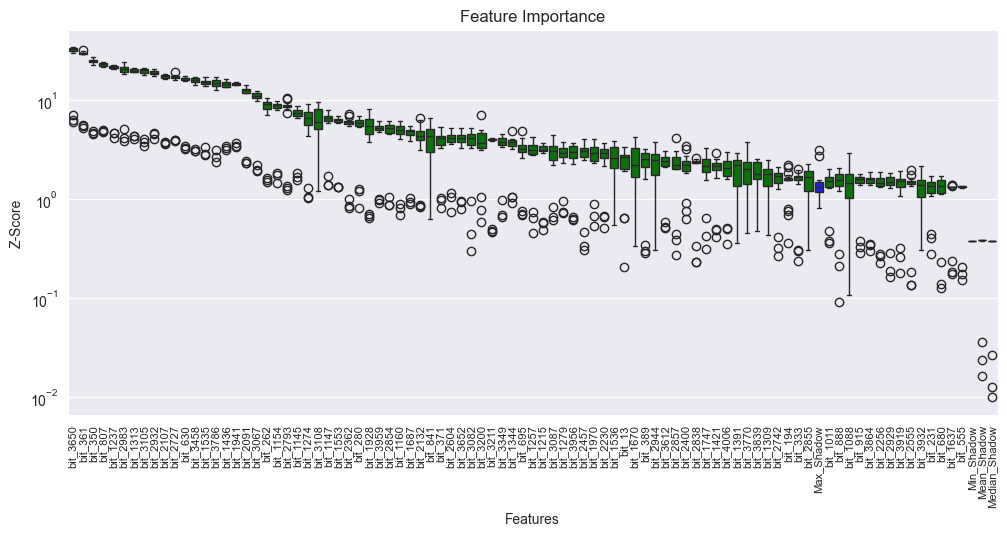

    -> Saved plot and 87 features selected.

--- Processing Target: mr ---


  0%|          | 0/20 [00:00<?, ?it/s]

29 attributes confirmed important: ['bit_1594', 'bit_2049', 'bit_3650', 'bit_630', 'bit_350', 'bit_971', 'bit_1101', 'bit_841', 'bit_1060', 'bit_2303', 'bit_3219', 'bit_2107', 'bit_1670', 'bit_692', 'bit_2929', 'bit_2793', 'bit_1905', 'bit_2766', 'bit_1145', 'bit_2974', 'bit_132', 'bit_441', 'bit_361', 'bit_3782', 'bit_1338', 'bit_4006', 'bit_2518', 'bit_1021', 'bit_262']
4025 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', 'bit_959', 'bit_3850', 'bit_1285', 'bit_1065', 'bit_3282', 'bit_59', 'bit_245', 'bit_2109', 'bit_2317', 'bit_1922', 'bit_2957', 'bit_3297', 'bit_738', 'bit_2710', 'bit_1112', 'bit_582', 'bit_3140', 'bit_3424', 'bit_3663', 'bit_3857', 'bit_422', 'bit_1223', 'bit_1506', 'bit_688', 'bit_464', 'bit_2222', 'bit_3125', 'bit_1281', 'bit_855', 'bit_2643', 'bit_2668', 'bit_1389', 'bit_3320', 'bit_1542', 'bit_2297', 'bit_1626', 'bit_2270', 'bit_22', 'bit_194', 'bit_1784', 'bit_677',

<Figure size 1200x600 with 0 Axes>

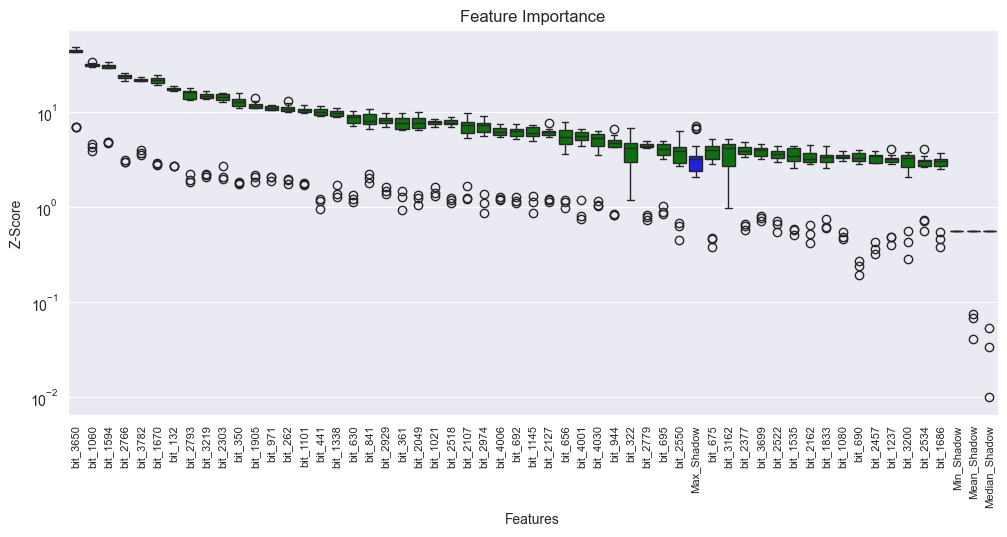

    -> Saved plot and 53 features selected.

--- Processing Target: pr ---


  0%|          | 0/20 [00:00<?, ?it/s]

59 attributes confirmed important: ['bit_1594', 'bit_2290', 'bit_3839', 'bit_2698', 'bit_1257', 'bit_3650', 'bit_2682', 'bit_807', 'bit_372', 'bit_1980', 'bit_3802', 'bit_3500', 'bit_630', 'bit_127', 'bit_3330', 'bit_191', 'bit_253', 'bit_2730', 'bit_2522', 'bit_439', 'bit_2413', 'bit_378', 'bit_2793', 'bit_1160', 'bit_2855', 'bit_3028', 'bit_4041', 'bit_45', 'bit_3733', 'bit_2722', 'bit_1274', 'bit_1638', 'bit_3108', 'bit_1145', 'bit_3873', 'bit_4030', 'bit_35', 'bit_1917', 'bit_1957', 'bit_3184', 'bit_695', 'bit_3875', 'bit_216', 'bit_785', 'bit_361', 'bit_991', 'bit_13', 'bit_3105', 'bit_3655', 'bit_119', 'bit_746', 'bit_2857', 'bit_2944', 'bit_2281', 'bit_34', 'bit_1313', 'bit_1475', 'bit_262', 'bit_960']
3979 attributes confirmed unimportant: ['bit_2309', 'bit_3522', 'bit_1825', 'bit_1449', 'bit_3217', 'bit_2550', 'bit_2472', 'bit_3505', 'bit_3913', 'bit_1986', 'bit_959', 'bit_3850', 'bit_1285', 'bit_1065', 'bit_3282', 'bit_59', 'bit_245', 'bit_2109', 'bit_2317', 'bit_1922', 'bit_

<Figure size 1200x600 with 0 Axes>

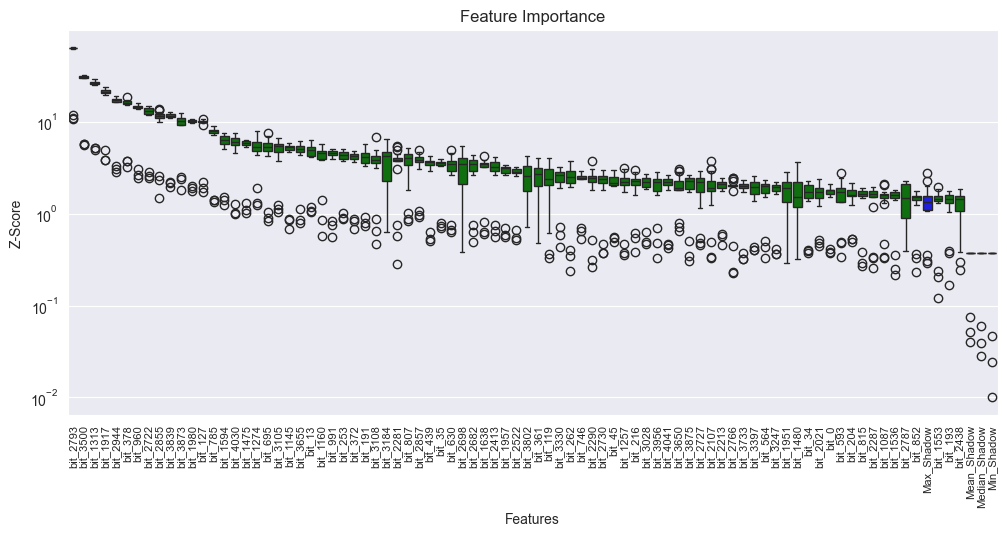

    -> Saved plot and 82 features selected.

Success! Z-scores matrix saved to 'boruta_zscores_matrix.csv'


In [13]:
zscore_results = []

# --- 2. LOOP PER TARGET ---
for i, target_name in enumerate(target_names):
    print(f"\n--- Processing Target: {target_name} ---")

    y_target = pd.Series(y[:, i], name=target_name)

    selector = BorutaShap(
        model=xgb_boruta,
        importance_measure='shap',
        classification=True
    )

    try:
        # Fit Boruta
        selector.fit(X=X_boruta, y=y_target, n_trials=BORUTA_TRIALS, sample=False, verbose=True)

        # 1. GET Z-SCORES
        # selector.history_x is a DataFrame where:
        # Rows = Trials (iterations), Columns = Features (Bits)
        # We take the mean across all trials to get a single score per bit.
        mean_z_scores = selector.history_x.mean(axis=0)
        mean_z_scores.name = target_name  # Set the row name to the receptor/target

        # Append to our results list
        zscore_results.append(mean_z_scores)

        # 2. STANDARD PLOTTING & CLEANUP (As before)
        selector.TentativeRoughFix()

        plt.figure(figsize=(12, 6))
        selector.plot(which_features='accepted', figsize=(12, 5))
        safe_name = target_name.replace('/', '_').replace(' ', '_')
        plt.title(f"Boruta Importance: {target_name}")
        plt.tight_layout()
        plt.savefig(f"boruta_plot_{safe_name}.png", dpi=300)
        plt.close()

        subset = selector.Subset()
        selected_features_per_target[target_name] = subset.columns.tolist()
        print(f"    -> Saved plot and {len(subset.columns)} features selected.")

    except Exception as e:
        print(f"    -> Failed for {target_name}: {e}")
        # Optional: Append a row of NaNs or 0s so the target isn't missing from the CSV
        # empty_row = pd.Series(0, index=feature_names, name=target_name)
        # zscore_results.append(empty_row)

# --- 3. EXPORT TO CSV ---
# Create DataFrame from the list of Series
# This aligns all bits automatically; if a bit was missing in one run (unlikely with same X), it handles it.
final_zscore_df = pd.DataFrame(zscore_results)

# Fill NaNs with 0 (if any)
final_zscore_df = final_zscore_df.fillna(0)

# Save to CSV
# Index (Rows) = Targets (Receptors)
# Columns = Bits (ECFP)
final_zscore_df.to_csv('boruta_zscores_matrix.csv', index=True)

print("\nSuccess! Z-scores matrix saved to 'boruta_zscores_matrix.csv'")